
               TABEL FREKUENSI               
       Grade         |      Frekuensi      
---------------------------------------------
         A           |          12         
         AB          |          8          
         B           |          4          
         BC          |          1          
         C           |          5          
         F           |          1          
---------------------------------------------
       TOTAL         |          31         


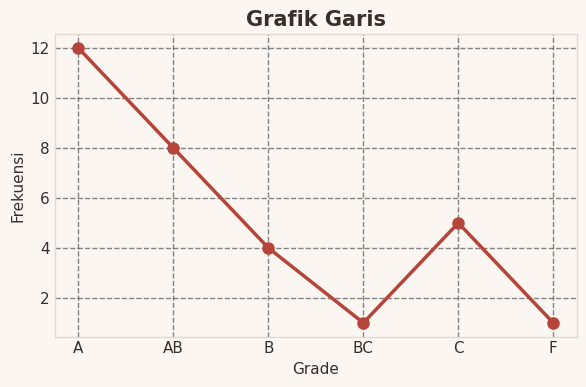

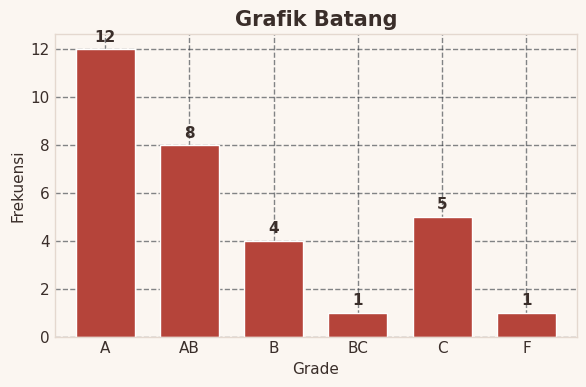

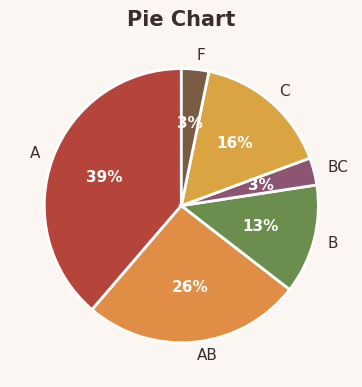

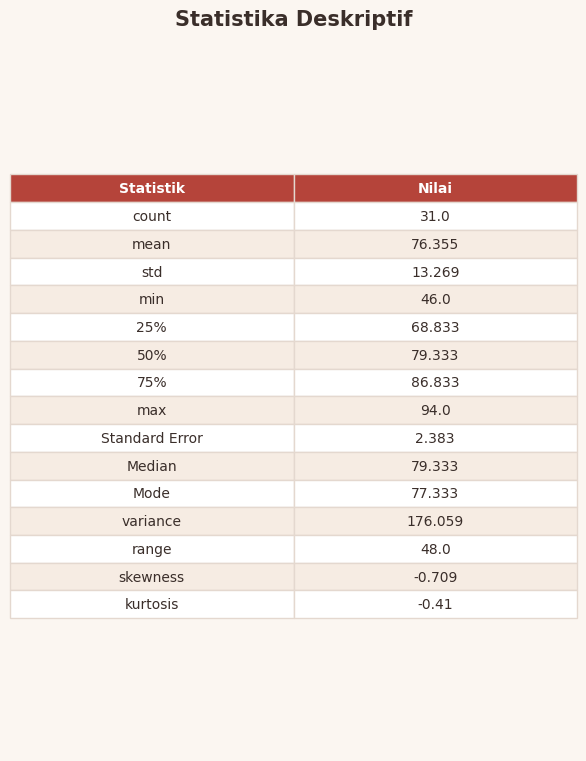

In [23]:
import pandas as pd
import matplotlib.pyplot as plt

# PENGATURAN TAMPILAN
PALET = ["#B5443A", "#E08E45", "#6B8E4E", "#8E5572", "#D9A441", "#7A5C45", "#C96F6F"]
WARNA_UTAMA = "#B5443A"
WARNA_TEKS = "#3A2E2A"
WARNA_GRID = "#E4D8CF"
WARNA_LATAR = "#FBF6F1"

plt.rcParams.update({
    "figure.figsize": (6, 4),
    "figure.facecolor": WARNA_LATAR,
    "axes.facecolor": WARNA_LATAR,
    "axes.edgecolor": WARNA_GRID,
    "axes.labelcolor": WARNA_TEKS,
    "axes.titlesize": 15,
    "axes.titleweight": "bold",
    "axes.titlecolor": WARNA_TEKS,
    "axes.labelsize": 11,
    "xtick.color": WARNA_TEKS,
    "ytick.color": WARNA_TEKS,
    "font.family": "DejaVu Sans",
})

# Sesuaikan path/lokasi file excel kamu
path = "aditya.xlsx"
dataraw = pd.read_excel(path)

# A. Pengorganisasian Data (Tabel Frekuensi)
datafrq = pd.crosstab(index=dataraw["Grade"], columns="Frekuensi")

print()
print("=" * 45)
print("TABEL FREKUENSI".center(45))
print("=" * 45)

print(f"{'Grade':^20} | {'Frekuensi':^20}")
print("-" * 45)

for grade, frekuensi in datafrq["Frekuensi"].items():
    print(f"{str(grade):^20} | {frekuensi:^20}")

print("-" * 45)
print(f"{'TOTAL':^20} | {datafrq['Frekuensi'].sum():^20}")
print("=" * 45)

warna_kategori = [PALET[i % len(PALET)] for i in range(len(datafrq))]

# B. Penyajian Data (Visualisasi)

# Grafik Garis
ax = datafrq.plot(
    title="Grafik Garis",
    color=WARNA_UTAMA,
    marker="o",
    markersize=8,
    linewidth=2.5,
    legend=False,
)
ax.set_xlabel("Grade")
ax.set_ylabel("Frekuensi")
plt.tight_layout()
plt.show()

# Grafik Batang
ax = datafrq.plot(
    kind="bar",
    title="Grafik Batang",
    color=warna_kategori,
    edgecolor="white",
    width=0.7,
    legend=False,
)
ax.set_xlabel("Grade")
ax.set_ylabel("Frekuensi")
ax.bar_label(ax.containers[0], padding=3, color=WARNA_TEKS, fontweight="bold")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Pie Chart
ax = datafrq.plot(
    kind="pie",
    y="Frekuensi",
    autopct="%1.0f%%",
    legend=False,
    title="Pie Chart",
    colors=warna_kategori,
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2},
    textprops={"color": WARNA_TEKS, "fontsize": 11},
)
ax.set_ylabel("")
for teks in ax.texts:
    if "%" in teks.get_text():
        teks.set_color("white")
        teks.set_fontweight("bold")
plt.tight_layout()
plt.show()

# C. Statistika Deskriptif
dataraw["Nilai"] = pd.to_numeric(dataraw["Nilai"], errors="coerce")
dt = dataraw["Nilai"]
stats = dt.describe()
stats["Standard Error"] = dt.sem()
stats["Median"] = dt.median()
stats["Mode"] = dt.mode().iloc[0]
stats["variance"] = dt.var()
stats["range"] = dt.max() - dt.min()
stats["skewness"] = dt.skew()
stats["kurtosis"] = dt.kurtosis()

# Tampilan tabel statistik dalam bentuk gambar (opsional, hanya menambah)
tabel = stats.round(3).to_frame(name="Nilai").reset_index()
tabel.columns = ["Statistik", "Nilai"]

fig, ax = plt.subplots(figsize=(6, 0.45 * len(tabel) + 1))
ax.axis("off")
ax.set_title("Statistika Deskriptif", pad=12)
tb = ax.table(
    cellText=tabel.values,
    colLabels=tabel.columns,
    cellLoc="center",
    loc="center",
)
tb.auto_set_font_size(False)
tb.set_fontsize(10)
tb.scale(1, 1.4)
for (baris, kolom), sel in tb.get_celld().items():
    sel.set_edgecolor(WARNA_GRID)
    if baris == 0:
        sel.set_facecolor(WARNA_UTAMA)
        sel.set_text_props(color="white", fontweight="bold")
    else:
        sel.set_facecolor("#FFFFFF" if baris % 2 else "#F6ECE3")
        sel.set_text_props(color=WARNA_TEKS)
plt.tight_layout()
plt.show()